In [ ]:
import zipfile
import os

zip_path = "/content/archive (5).zip"   # your zip file name
extract_path = "/content/unzipped_data" # folder where files will be extracted

# Create folder if not exists
os.makedirs(extract_path, exist_ok=True)

# Unzip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipping completed!")
print("Files:", os.listdir(extract_path))


Unzipping completed!
Files: ['multilingual_dataset_train_final.csv', 'multilingual_dataset_test_final.csv']


In [ ]:
import numpy as np

# Ensure labels are numeric, coercing errors to NaN
train_df['labels'] = pd.to_numeric(train_df['labels'], errors='coerce')

# Drop rows where 'labels' is NaN before converting to int
train_df.dropna(subset=['labels'], inplace=True)

train_df['labels'] = train_df['labels'].astype(int)

print("Data types after converting 'labels' to int:")
print(train_df.dtypes)

print("\nUnique values in 'labels' column after conversion:")
print(train_df['labels'].unique())

Data types after converting 'labels' to int:
Unnamed: 0    object
text          object
labels         int64
dtype: object

Unique values in 'labels' column after conversion:
[1 0]


In [ ]:
import pandas as pd

train_df = pd.read_csv('/content/unzipped_data/multilingual_dataset_train_final.csv', on_bad_lines='skip', quotechar='"', engine='python')

print(train_df.head())
print(train_df.columns)

  Unnamed: 0                                               text  labels
0          0  November 11, 2016 Islamic State executes score...     1.0
1          1  Email \nVladimir Lenin, the first dictator of ...     1.0
2          2  Lena Dunham claims (claims!) she is losing wei...     0.0
3          3  In obscure data tables buried deep in its 2016...     0.0
4          4  21st Century WireYesterday, violence broke out...     1.0
Index(['Unnamed: 0', 'text', 'labels'], dtype='object')


## Load Test Data

### Subtask:
Load the 'multilingual_dataset_test_final.csv' file into a pandas DataFrame.


In [ ]:
import pandas as pd

test_df = pd.read_csv('/content/unzipped_data/multilingual_dataset_test_final.csv', on_bad_lines='skip', quotechar='"', engine='python')

print(test_df.head())
print(test_df.columns)

  Unnamed: 0                                               text labels
0          0  Federal prosecutors in Manhattan have evidence...      0
1          1  Sometimes in life you just need to state the o...      1
2          2  Racists and Confederate flag worshipers may be...      1
3          3  The footage is grainy, randomly framed. A pit ...      0
4          4  Streep s shameful attempt to paint Trump as a ...      1
Index(['Unnamed: 0', 'text', 'labels'], dtype='object')


## Preprocess Data

### Subtask:
Perform initial preprocessing steps on both the training and test datasets. This may include handling missing values, encoding categorical features, or other necessary transformations. I will inspect the data to determine the most appropriate preprocessing steps.


In [ ]:
print("Train DataFrame Info:")
train_df.info()
print("\nTrain DataFrame Missing Values:")
print(train_df.isnull().sum())

print("\nTest DataFrame Info:")
test_df.info()
print("\nTest DataFrame Missing Values:")
print(test_df.isnull().sum())

Train DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66202 entries, 0 to 66201
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  66202 non-null  object 
 1   text        66200 non-null  object 
 2   labels      66197 non-null  float64
dtypes: float64(1), object(2)
memory usage: 1.5+ MB

Train DataFrame Missing Values:
Unnamed: 0    0
text          2
labels        5
dtype: int64

Test DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22973 entries, 0 to 22972
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  22973 non-null  object
 1   text        22968 non-null  object
 2   labels      22960 non-null  object
dtypes: object(3)
memory usage: 538.6+ KB

Test DataFrame Missing Values:
Unnamed: 0     0
text           5
labels        13
dtype: int64


In [ ]:
train_df.drop('Unnamed: 0', axis=1, inplace=True)
test_df.drop('Unnamed: 0', axis=1, inplace=True)

print("Train DataFrame after dropping 'Unnamed: 0':")
print(train_df.head())
print("\nTest DataFrame after dropping 'Unnamed: 0':")
print(test_df.head())

Train DataFrame after dropping 'Unnamed: 0':
                                                text  labels
0  November 11, 2016 Islamic State executes score...     1.0
1  Email \nVladimir Lenin, the first dictator of ...     1.0
2  Lena Dunham claims (claims!) she is losing wei...     0.0
3  In obscure data tables buried deep in its 2016...     0.0
4  21st Century WireYesterday, violence broke out...     1.0

Test DataFrame after dropping 'Unnamed: 0':
                                                text labels
0  Federal prosecutors in Manhattan have evidence...      0
1  Sometimes in life you just need to state the o...      1
2  Racists and Confederate flag worshipers may be...      1
3  The footage is grainy, randomly framed. A pit ...      0
4  Streep s shameful attempt to paint Trump as a ...      1


In [ ]:
print("Before dropping NaNs in test_df:")
print(test_df.isnull().sum())

test_df.dropna(subset=['text', 'labels'], inplace=True)

print("\nAfter dropping NaNs in test_df:")
print(test_df.isnull().sum())

Before dropping NaNs in test_df:
text       5
labels    13
dtype: int64

After dropping NaNs in test_df:
text      0
labels    0
dtype: int64


In [ ]:
print("Before converting 'labels' in test_df:")
print(test_df['labels'].value_counts(dropna=False))

test_df['labels'] = pd.to_numeric(test_df['labels'], errors='coerce')
test_df.dropna(subset=['labels'], inplace=True)

print("\nAfter converting and dropping NaNs in 'labels' of test_df:")
print(test_df['labels'].value_counts(dropna=False))
print(test_df.info())

Before converting 'labels' in test_df:
labels
1                                                                                                                       11528
0                                                                                                                       11430
 statute and regulation. Each person in this situation costs the government at multiple levels millions of dollars.         1
 ge out go live off some other country and see how that works out for you TheFulishBastid                                   1
Name: count, dtype: int64

After converting and dropping NaNs in 'labels' of test_df:
labels
1.0    11528
0.0    11430
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 22958 entries, 0 to 22972
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   text    22958 non-null  object 
 1   labels  22958 non-null  float64
dtypes: float64(1), object(1)
memory usage: 538.1+ KB


## Text Vectorization

### Subtask:
Convert the 'text' data into numerical features using a technique like TF-IDF or Word Embeddings for both training and test datasets. This is a crucial step for preparing text data for machine learning models.


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

print("TfidfVectorizer imported successfully.")

TfidfVectorizer imported successfully.


In [ ]:
print("Missing values in 'text' column of train_df before dropping:")
print(train_df['text'].isnull().sum())

train_df.dropna(subset=['text'], inplace=True)

print("\nMissing values in 'text' column of train_df after dropping:")
print(train_df['text'].isnull().sum())

Missing values in 'text' column of train_df before dropping:
2

Missing values in 'text' column of train_df after dropping:
0


**Reasoning**:
Now that the missing values in `train_df['text']` have been handled, I will re-run the `TfidfVectorizer` to convert the text data into numerical features for both training and test datasets. This should resolve the `AttributeError` encountered previously.



In [ ]:
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(train_df['text'])
X_test_tfidf = vectorizer.transform(test_df['text'])

print("Shape of X_train_tfidf:", X_train_tfidf.shape)
print("Shape of X_test_tfidf:", X_test_tfidf.shape)

Shape of X_train_tfidf: (66200, 507454)
Shape of X_test_tfidf: (22958, 507454)


labels
1.0    33355
0.0    32842
Name: count, dtype: int64


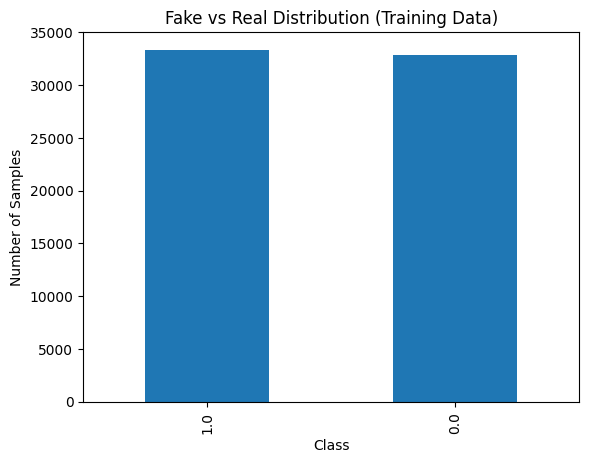

In [ ]:
import matplotlib.pyplot as plt

# Count fake vs real
counts = train_df['labels'].value_counts()
print(counts)

# Plot graph
plt.figure()
counts.plot(kind='bar')
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("Fake vs Real Distribution (Training Data)")
plt.show()

SVM MODEL

Accuracy: 0.9126230507883962

Classification Report:

              precision    recall  f1-score   support

         0.0       0.92      0.91      0.91     11430
         1.0       0.91      0.92      0.91     11528

    accuracy                           0.91     22958
   macro avg       0.91      0.91      0.91     22958
weighted avg       0.91      0.91      0.91     22958


Confusion Matrix:
 [[10362  1068]
 [  938 10590]]


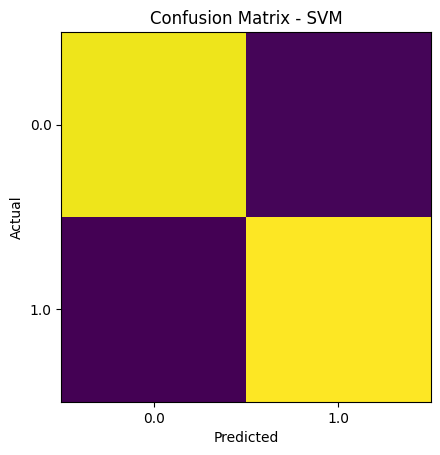

In [ ]:
# Imports
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

# Change these column names based on your dataset
TEXT_COLUMN = "text"
LABEL_COLUMN = "labels" # Corrected to 'labels'

# Features and labels are already prepared in previous steps
# X_train_tfidf and X_test_tfidf are available globally
# y_train and y_test can be derived from train_df and test_df
y_train = train_df[LABEL_COLUMN].values
y_test = test_df[LABEL_COLUMN].values

# Explicitly handle NaNs in y_train and y_test and align with X_train_tfidf/X_test_tfidf
# (Although previous steps should have cleaned them, this adds robustness)

# Get non-NaN indices for y_train
non_nan_indices_train = ~np.isnan(y_train)

# Filter y_train and X_train_tfidf
y_train_cleaned = y_train[non_nan_indices_train]
X_train_tfidf_cleaned = X_train_tfidf[non_nan_indices_train]

# Get non-NaN indices for y_test
non_nan_indices_test = ~np.isnan(y_test)

# Filter y_test and X_test_tfidf
y_test_cleaned = y_test[non_nan_indices_test]
X_test_tfidf_cleaned = X_test_tfidf[non_nan_indices_test]

# SVM Model
svm_model = LinearSVC()
svm_model.fit(X_train_tfidf_cleaned, y_train_cleaned)

# Predictions
y_pred = svm_model.predict(X_test_tfidf_cleaned)

# Accuracy
print("Accuracy:", accuracy_score(y_test_cleaned, y_pred))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test_cleaned, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test_cleaned, y_pred)

print("\nConfusion Matrix:\n", cm)

# Plot confusion matrix (NO colors used)
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(np.arange(len(set(y_test_cleaned))), set(y_test_cleaned))
plt.yticks(np.arange(len(set(y_test_cleaned))), set(y_test_cleaned))
plt.show()

Accuracy: 0.825158985974388

Classification Report:

              precision    recall  f1-score   support

         0.0       0.83      0.82      0.82     11430
         1.0       0.82      0.83      0.83     11528

    accuracy                           0.83     22958
   macro avg       0.83      0.83      0.83     22958
weighted avg       0.83      0.83      0.83     22958


Confusion Matrix:
 [[9335 2095]
 [1919 9609]]


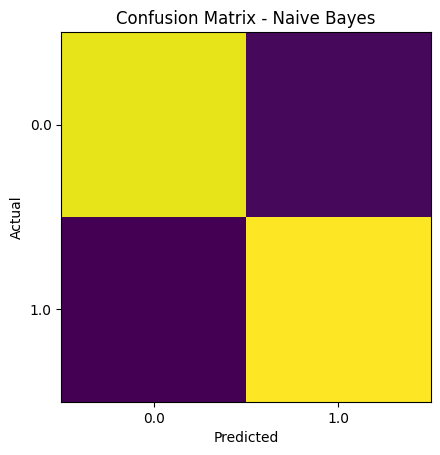

In [ ]:
# Imports
import pandas as pd
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

# ============================
# Uses already prepared data:
# X_train_tfidf_cleaned
# X_test_tfidf_cleaned
# y_train_cleaned
# y_test_cleaned
# ============================

# Naive Bayes Model
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf_cleaned, y_train_cleaned)

# Predictions
y_pred_nb = nb_model.predict(X_test_tfidf_cleaned)

# Accuracy
print("Accuracy:", accuracy_score(y_test_cleaned, y_pred_nb))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test_cleaned, y_pred_nb))

# Confusion Matrix
cm = confusion_matrix(y_test_cleaned, y_pred_nb)

print("\nConfusion Matrix:\n", cm)

# Plot confusion matrix (NO colors used)
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(np.arange(len(set(y_test_cleaned))), set(y_test_cleaned))
plt.yticks(np.arange(len(set(y_test_cleaned))), set(y_test_cleaned))
plt.show()


LOGISTIC REGRESSION


Accuracy: 0.894503005488283

Classification Report:

              precision    recall  f1-score   support

         0.0       0.91      0.88      0.89     11430
         1.0       0.88      0.91      0.90     11528

    accuracy                           0.89     22958
   macro avg       0.89      0.89      0.89     22958
weighted avg       0.89      0.89      0.89     22958


Confusion Matrix:
 [[10049  1381]
 [ 1041 10487]]


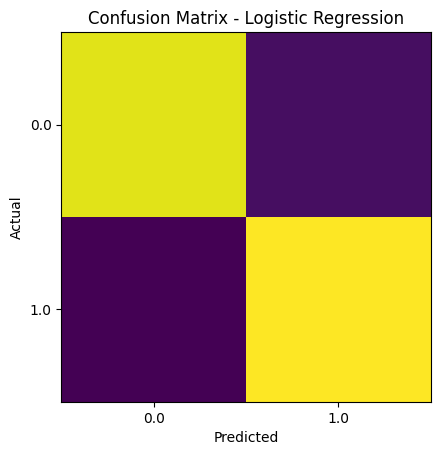

In [ ]:
# Imports
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

# ============================
# Uses already prepared data:
# X_train_tfidf_cleaned
# X_test_tfidf_cleaned
# y_train_cleaned
# y_test_cleaned
# ============================

# Logistic Regression Model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf_cleaned, y_train_cleaned)

# Predictions
y_pred_lr = lr_model.predict(X_test_tfidf_cleaned)

# Accuracy
print("Accuracy:", accuracy_score(y_test_cleaned, y_pred_lr))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test_cleaned, y_pred_lr))

# Confusion Matrix
cm = confusion_matrix(y_test_cleaned, y_pred_lr)

print("\nConfusion Matrix:\n", cm)

# Plot confusion matrix (NO colors used)
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(np.arange(len(set(y_test_cleaned))), set(y_test_cleaned))
plt.yticks(np.arange(len(set(y_test_cleaned))), set(y_test_cleaned))
plt.show()


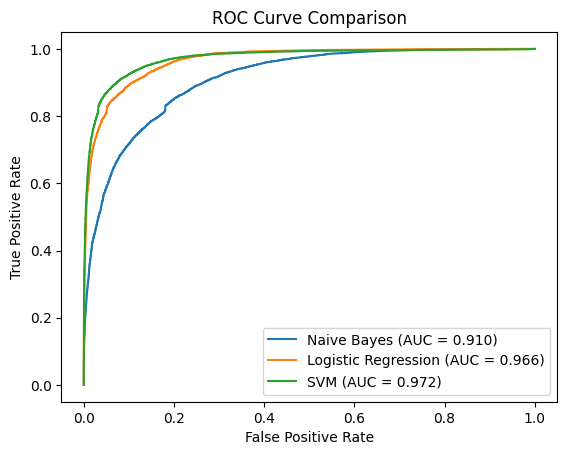

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ============================
# Get scores from models
# ============================

# Naive Bayes probabilities
nb_probs = nb_model.predict_proba(X_test_tfidf_cleaned)[:, 1]

# Logistic Regression probabilities
lr_probs = lr_model.predict_proba(X_test_tfidf_cleaned)[:, 1]

# SVM decision scores (not probabilities)
svm_scores = svm_model.decision_function(X_test_tfidf_cleaned)

# ============================
# ROC Curve values
# ============================

fpr_nb, tpr_nb, _ = roc_curve(y_test_cleaned, nb_probs)
fpr_lr, tpr_lr, _ = roc_curve(y_test_cleaned, lr_probs)
fpr_svm, tpr_svm, _ = roc_curve(y_test_cleaned, svm_scores)

# AUC scores
auc_nb = auc(fpr_nb, tpr_nb)
auc_lr = auc(fpr_lr, tpr_lr)
auc_svm = auc(fpr_svm, tpr_svm)

# ============================
# Plot ROC Curve (single plot, no colors specified)
# ============================

plt.figure()

plt.plot(fpr_nb, tpr_nb, label=f"Naive Bayes (AUC = {auc_nb:.3f})")
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})")
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc_svm:.3f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


DEEP LEARNING MODELS

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense


In [ ]:
import numpy as np
import pandas as pd

# Columns
TEXT_COLUMN = "text"
LABEL_COLUMN = "labels"

# Ensure test_df labels are also int
test_df['labels'] = pd.to_numeric(test_df['labels'], errors='coerce')
test_df.dropna(subset=['labels'], inplace=True)
test_df['labels'] = test_df['labels'].astype(int)

# Combine train_df and test_df into a single df for tokenization and splitting
df = pd.concat([train_df, test_df], ignore_index=True)

X = df[TEXT_COLUMN].astype(str)
y = df[LABEL_COLUMN]

# Encode labels if they are fake/real
le = LabelEncoder()
y = le.fit_transform(y)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Data prepared for deep learning models.")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Data prepared for deep learning models.
X_train shape: (71326,)
y_train shape: (71326,)
X_test shape: (17832,)
y_test shape: (17832,)


In [ ]:
max_words = 20000
max_len = 200

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)


CNN MODEL

In [ ]:
model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()
history = model.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)
y_probs = model.predict(X_test_pad)
y_pred = (y_probs > 0.5).astype(int)
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 246s 119ms/step - accuracy: 0.8257 - loss: 0.3293 - val_accuracy: 0.8967 - val_loss: 0.2023
Epoch 2/5
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 245s 111ms/step - accuracy: 0.9319 - loss: 0.1272 - val_accuracy: 0.9016 - val_loss: 0.2019
Epoch 3/5
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 218s 109ms/step - accuracy: 0.9511 - loss: 0.0809 - val_accuracy: 0.9062 - val_loss: 0.2349
Epoch 4/5
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 262s 109ms/step - accuracy: 0.9566 - loss: 0.0715 - val_accuracy: 0.9037 - val_loss: 0.2825
Epoch 5/5
2007/2007 ━━━━━━━━━━━━━━━━━━━━ 219s 109ms/step - accuracy: 0.9572 - loss: 0.0673 - val_accuracy: 0.9002 - val_loss: 0.3065
558/558 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step
Accuracy: 0.9028151637505608

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.96      0.91      8854
           1       0.96      0.84      0.90      8977
           2       0.00      0.00      0.00         1

    accuracy        

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Confusion Matrix:
 [[8543  311    0]
 [1421 7556    0]
 [   0    1    0]]


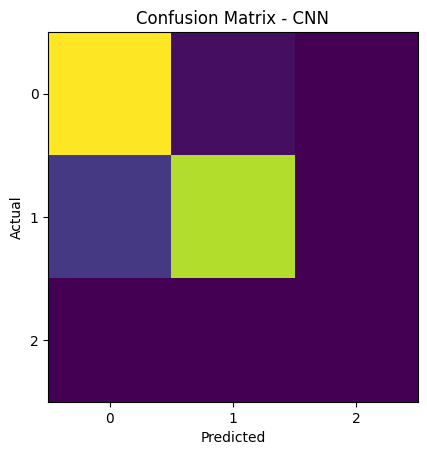

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n", cm)

# Plot confusion matrix (no colors used)
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix - CNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(np.arange(cm.shape[1]))
plt.yticks(np.arange(cm.shape[0]))
plt.show()
